# Weekly Project (Beginner Level): Customer Segmentation

**Goal:** Group mall customers into segments based on their income and spending habits, so a business can target each group differently.

**Type:** Unsupervised Learning (Clustering) — there is no "correct answer" given, the model finds groups on its own.

**Dataset:** Mall Customers — 200 customers, with Gender, Age, Annual Income, and Spending Score.

This notebook is written for beginners — every step is explained in plain language, and the code is kept simple on purpose.

## Step 1: Import Libraries

We only need pandas for data handling, matplotlib/seaborn for charts, and scikit-learn for the clustering model.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style('whitegrid')

## Step 2: Load the Dataset

In [3]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print("Number of customers:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of customers: 200
Number of columns: 5


**What do the columns mean?**

- `CustomerID` — just an ID number, not useful for grouping
- `Gender` — Male / Female
- `Age` — customer's age
- `Annual Income (k$)` — yearly income in thousands of dollars
- `Spending Score (1-100)` — a score the mall gives customers based on their spending behavior (100 = spends a lot, 1 = spends very little)

## Step 3: Basic Data Check

Before building anything, we check the data is clean.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


Good — no missing values, so we don't need to clean anything.

## Step 4: Simple Exploration (EDA)

Let's look at income and spending score, since these will be the two features we use to group customers.

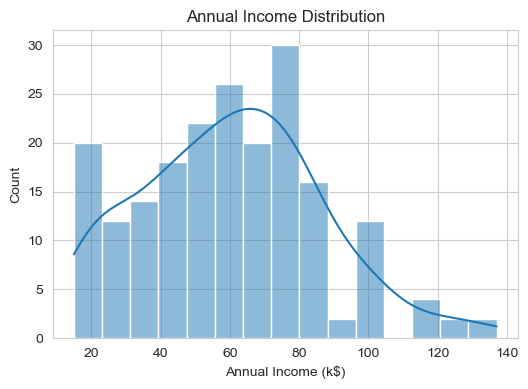

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df['Annual Income (k$)'], bins=15, kde=True)
plt.title('Annual Income Distribution')
plt.show()

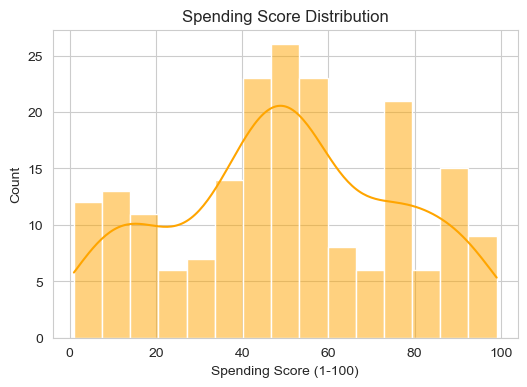

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df['Spending Score (1-100)'], bins=15, kde=True, color='orange')
plt.title('Spending Score Distribution')
plt.show()

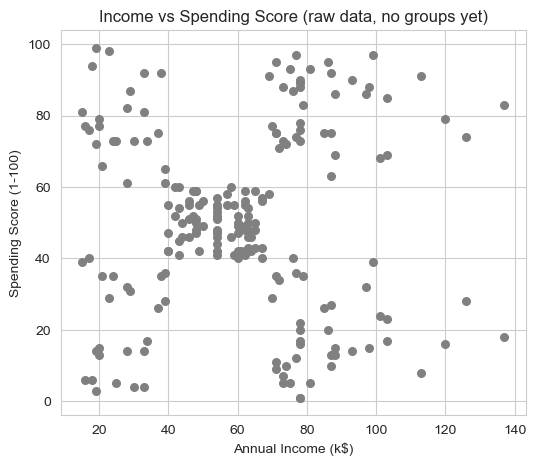

In [9]:
plt.figure(figsize=(6,5))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], s=30, color='gray')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Income vs Spending Score (raw data, no groups yet)')
plt.show()

Just by looking at this scatter plot, you can already see some natural groupings — that's exactly what K-Means will find for us automatically.

## Step 5: Prepare the Data for Clustering

We only use `Annual Income` and `Spending Score` for clustering, since these two features are what we care about for segmenting customers. We also scale the features so both are on a similar range (important for K-Means, which relies on distance).

In [10]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Step 6: The Elbow Method — Choosing the Number of Segments

We need to decide how many customer groups (K) to create. The Elbow Method helps: we try different K values and plot the 'inertia' (how tight each cluster is). We look for the point where the curve bends — that's usually a good K.

d:\minconds\envs\prac_eda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\minconds\envs\prac_eda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\minconds\envs\prac_eda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\minconds\envs\prac_eda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

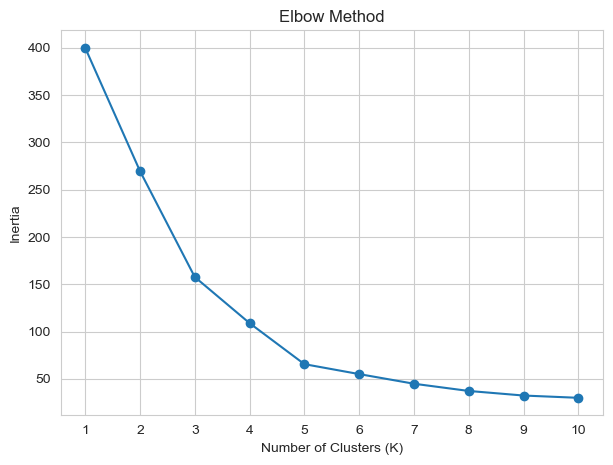

In [11]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(7,5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(list(k_range))
plt.show()

The curve bends around **K = 5** — after that, adding more clusters doesn't reduce inertia much. So we'll use 5 customer segments.

## Step 7: Apply K-Means with K = 5

In [12]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Segment'] = kmeans.fit_predict(X_scaled)

df.head()

d:\minconds\envs\prac_eda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Segment
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Step 8: Visualize the Customer Segments

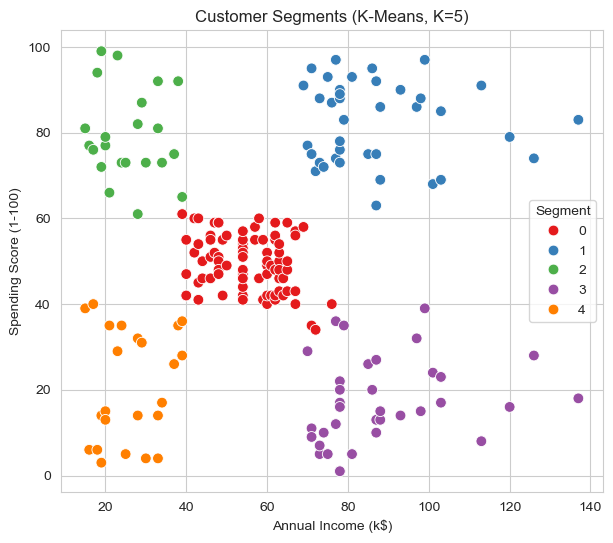

In [13]:
plt.figure(figsize=(7,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Segment', palette='Set1', s=60)
plt.title('Customer Segments (K-Means, K=5)')
plt.show()

Each color is a customer segment K-Means found on its own, just from income and spending patterns.

## Step 9: Understand Each Segment

Let's look at the average income and spending score per segment, so we can describe each group in plain language.

In [14]:
segment_summary = df.groupby('Segment')[['Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
segment_summary['Number of Customers'] = df['Segment'].value_counts().sort_index()
segment_summary

,Annual Income (k$),Spending Score (1-100),Number of Customers
Segment,,,
0,55.3,49.5,81
1,86.5,82.1,39
2,25.7,79.4,22
3,88.2,17.1,35
4,26.3,20.9,23


**In simple words, the 5 segments usually look like this:**

- **High income, high spending** → best customers, target them with premium offers
- **High income, low spending** → has money but doesn't spend here, try to win them over with better engagement
- **Low income, high spending** → spends a lot despite lower income, keep them happy with loyalty deals
- **Low income, low spending** → budget-conscious, offer discounts/value deals
- **Average income, average spending** → the "typical" customer, general marketing works fine

(Exact numbers are shown in the table above — check which row matches which description.)

## Summary

- We loaded the Mall Customers dataset (200 customers) and confirmed it had no missing values.
- We explored income and spending score with simple charts.
- We used the Elbow Method to decide on 5 customer segments.
- We applied K-Means clustering using only Income and Spending Score, and visualized the resulting segments.
- We summarized each segment's average income/spending so the results can actually be used for business decisions (e.g., marketing strategy).

**Next steps for going beyond beginner level:** try adding `Age` as a third feature, compare different K values, or use PCA if more features are added later.